In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data=pd.read_csv("memory_strength_dataset_cleaned_2.csv")

In [25]:
data.head(5)

,revision_timing,nth_revision,sleep_duration,topic_difficulty,study_duration,session_time,retention,S
0,56.312171,7,7.190609,7,85.791568,2,61.106404,114.327011
1,2.495917,1,8.053991,6,10.132390,3,98.713498,192.757354
2,24.313371,9,6.673295,9,59.508954,2,72.257539,74.825677
3,235.882474,6,4.193669,7,12.255043,0,0.247996,39.316935
4,138.330092,6,7.269977,8,15.846049,1,14.729763,72.223718


In [26]:
from sklearn.model_selection import train_test_split

x=data[
    ["nth_revision",
         "sleep_duration",
         "topic_difficulty",
         "study_duration",
         "session_time",
         "retention",
         "revision_timing"]
]
y=data["S"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training set size:",x_train.shape[0])
print("Test set size:",x_test.shape[0])
print("Training set size:",y_train.shape[0])
print("Test set size:",y_test.shape[0])

Training set size: 2171
Test set size: 543
Training set size: 2171
Test set size: 543


In [27]:
from sklearn.linear_model import  LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("Mean Squared Error:",mse)
print("R^2 Score:",r2)
print("Mean Absolute Error:",mae)

Mean Squared Error: 504.9385048095881
R^2 Score: 0.4989072837404258
Mean Absolute Error: 14.682099235298134


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)
y_rf_pred=rf_model.predict(x_test)
rf_mse=mean_squared_error(y_test,y_rf_pred)
rf_r2=r2_score(y_test,y_rf_pred)
rf_mae=mean_absolute_error(y_test,y_rf_pred)
print("Random Forest Mean Squared Error:",rf_mse)
print("Random Forest R^2 Score:",rf_r2)
print("Random Forest Mean Absolute Error:",rf_mae) 

Random Forest Mean Squared Error: 270.16509492423694
Random Forest R^2 Score: 0.7318925770868624
Random Forest Mean Absolute Error: 10.726070527129885


In [29]:
from xgboost import XGBRegressor
xgb_model=XGBRegressor(n_estimators=100,random_state=42)
print(x.columns.tolist())
xgb_model.fit(x_train,y_train)
y_xgb_pred=xgb_model.predict(x_test)
xgb_mse=mean_squared_error(y_test,y_xgb_pred)
xgb_r2=r2_score(y_test,y_xgb_pred)
xgb_mae=mean_absolute_error(y_test,y_xgb_pred)
print("XGBoost Mean Squared Error:",xgb_mse)
print("XGBoost R^2 Score:",xgb_r2)
print("XGBoost Mean Absolute Error:",xgb_mae)

['nth_revision', 'sleep_duration', 'topic_difficulty', 'study_duration', 'session_time', 'retention', 'revision_timing']
XGBoost Mean Squared Error: 129.80943509731915
XGBoost R^2 Score: 0.8711792390371069
XGBoost Mean Absolute Error: 7.259791515546614


In [30]:
from sklearn.model_selection import cross_val_score
rf_cv_scores=cross_val_score(rf_model,x,y,cv=5,scoring="r2")
print("Random Forest Cross-Validation R^2 Scores:",rf_cv_scores)
print("Random Forest Average Cross-Validation R^2 Score:",rf_cv_scores.mean())

Random Forest Cross-Validation R^2 Scores: [0.76452967 0.72605601 0.7535207  0.7799268  0.79730957]
Random Forest Average Cross-Validation R^2 Score: 0.7642685511052907


In [31]:
xgb_scores=cross_val_score(xgb_model,x,y,cv=5,scoring="r2")
print("XGBoost Cross-Validation R^2 Scores:",xgb_scores)
print("XGBoost Average Cross-Validation R^2 Score:",xgb_scores.mean())

XGBoost Cross-Validation R^2 Scores: [0.89904176 0.87625883 0.89965113 0.88722066 0.90902718]
XGBoost Average Cross-Validation R^2 Score: 0.894239912229042


In [32]:
import joblib
joblib.dump(xgb_model,"xgb_model.pkl")


['xgb_model.pkl']

In [33]:
print(data["S"].describe())

count    2714.000000
mean       81.929597
std        31.109380
min         7.620537
25%        61.369644
50%        80.145203
75%        99.284812
max       217.586111
Name: S, dtype: float64


In [34]:
print(data.groupby("nth_revision")["S"].mean())

nth_revision
0    48.225989
1    62.391279
2    72.365197
3    77.301162
4    83.672295
5    87.158178
6    90.107576
7    94.708874
8    98.119768
9    98.945603
Name: S, dtype: float64


In [35]:
model=joblib.load("xgb_model.pkl")
test = pd.DataFrame([{
    "nth_revision": 5,
    "sleep_duration": 8,
    "topic_difficulty": 2,
    "study_duration": 90,
    "session_time": 10,
    "retention": 96,
    "revision_timing": 48
}])

print(model.predict(test))

[216.86934]


In [36]:
times = range(1,101)

s_values = []

for t in times:

    test = pd.DataFrame([{
        "nth_revision":5,
        "sleep_duration":8,
        "topic_difficulty":2,
        "study_duration":90,
        "session_time":10,
        "retention":96,
        "revision_timing":t
    }])

    s = model.predict(test)[0]

    s_values.append(s)
    

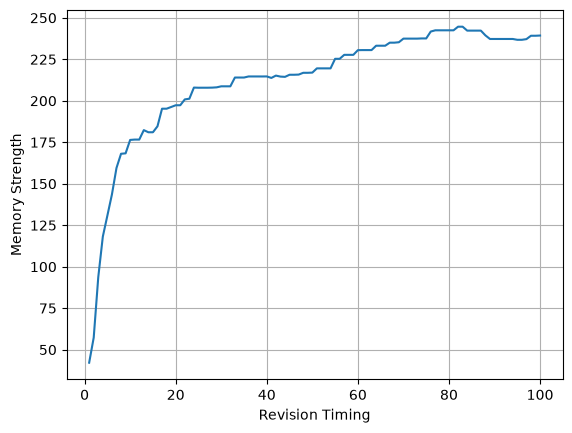

In [37]:


plt.plot(times,s_values)
plt.xlabel("Revision Timing")
plt.ylabel("Memory Strength")
plt.grid(True)
plt.show()

correlation between s and other variables

In [40]:
cor=data.corr(numeric_only=True)
print(cor["S"].sort_values(ascending=False))

S                   1.000000
nth_revision        0.474561
revision_timing     0.328086
sleep_duration      0.209842
study_duration      0.105097
retention           0.068535
session_time       -0.100633
topic_difficulty   -0.244248
Name: S, dtype: float64
